## Load Inspect DataSet

In [8]:
import pandas as pd
df = pd.read_csv("dataset/retail_sales_csv.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [9]:
df.shape

(1000, 9)

In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[us](1), int64(5), str(3)
memory usage: 70.4 KB


In [46]:
df.duplicated().sum()

np.int64(0)

In [47]:
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


In [54]:
df[["Age","Quantity","Price per Unit","Total Amount"]] .agg(
    ["mean","median","std"]
    )

,Age,Quantity,Price per Unit,Total Amount
mean,41.39200,2.514000,179.890000,456.000000
median,42.00000,3.000000,50.000000,135.000000
std,13.68143,1.132734,189.681356,559.997632


 Data Quality Check

We check for missing values to identify incomplete records in the dataset.

In [59]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [60]:
df.isna().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

#Monthly sales analysis

In [25]:
df["Date"] = pd.to_datetime(df["Date"])

In [26]:
df["Date"].dtype

dtype('<M8[us]')

In [27]:
df["Month"] = df["Date"].dt.month

In [28]:
df[["Date", "Month"]].head()

,Date,Month
0,2023-11-24,11
1,2023-02-27,2
2,2023-01-13,1
3,2023-05-21,5
4,2023-05-06,5


In [29]:
monthly_sales = df.groupby("Month")["Total Amount"].sum()

monthly_sales


Month
1     36980
2     44060
3     28990
4     33870
5     53150
6     36715
7     35465
8     36960
9     23620
10    46580
11    34920
12    44690
Name: Total Amount, dtype: int64

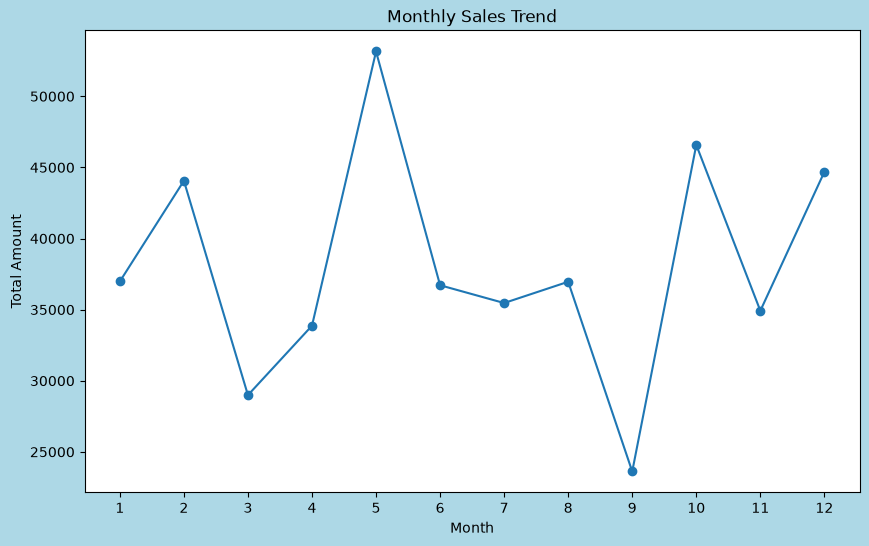

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6),facecolor="lightblue")

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Amount")
plt.xticks(range(1, 13))

plt.show()

##   Quarterly sales analysis

In [31]:
df["Quarter"] = df["Date"].dt.quarter

In [32]:
df[["Date", "Quarter"]].head()

,Date,Quarter
0,2023-11-24,4
1,2023-02-27,1
2,2023-01-13,1
3,2023-05-21,2
4,2023-05-06,2


In [33]:
quarterly_sales = df.groupby("Quarter")["Total Amount"].sum()

quarterly_sales

Quarter
1    110030
2    123735
3     96045
4    126190
Name: Total Amount, dtype: int64

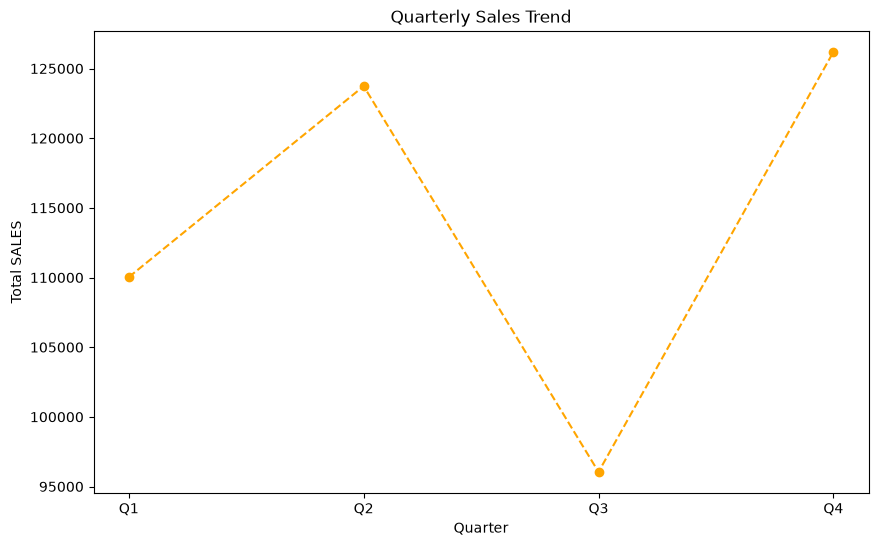

In [64]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.plot(quarterly_sales.index, quarterly_sales.values, marker='o',color='orange',linestyle='--')
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total SALES")
plt.xticks([1,2,3,4],["Q1","Q2","Q3","Q4"])
plt.show()


##   Gender analysis

In [37]:
gender_counts =df["Gender"].value_counts()
gender_counts

Gender
Female    510
Male      490
Name: count, dtype: int64

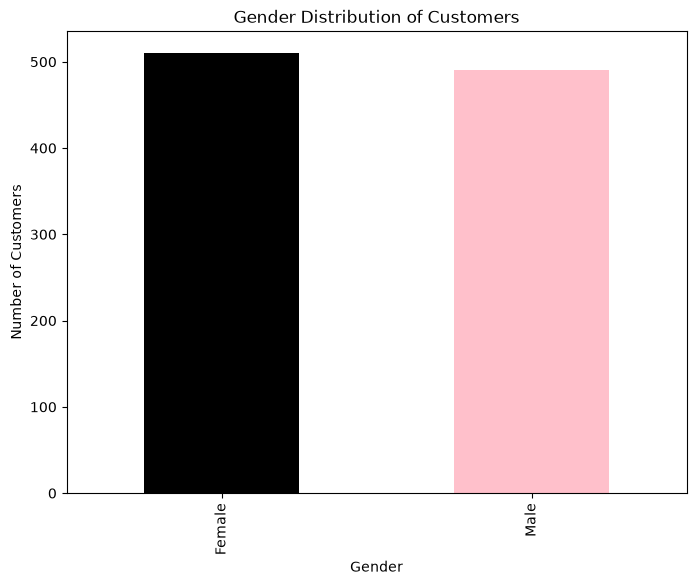

In [66]:
plt.figure(figsize=(8,6))
gender_counts.plot(kind='bar', color=['black','pink'])
plt.title("Gender Distribution of Customers")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

## Age Group Analysis

In [39]:
df["Age"].describe()

count    1000.00000
mean       41.39200
std        13.68143
min        18.00000
25%        29.00000
50%        42.00000
75%        53.00000
max        64.00000
Name: Age, dtype: float64

In [40]:
bins = [0, 17, 24, 34, 44, 54, 64, 100]

labels = [
    "Under 18",
    "18-24",
    "25-34",
    "35-44",
    "45-54",
    "55-64",
    "65+"
]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

In [41]:
age_group_counts = df["Age Group"].value_counts().sort_index()

age_group_counts

Age Group
Under 18      0
18-24       149
25-34       203
35-44       207
45-54       225
55-64       216
65+           0
Name: count, dtype: int64

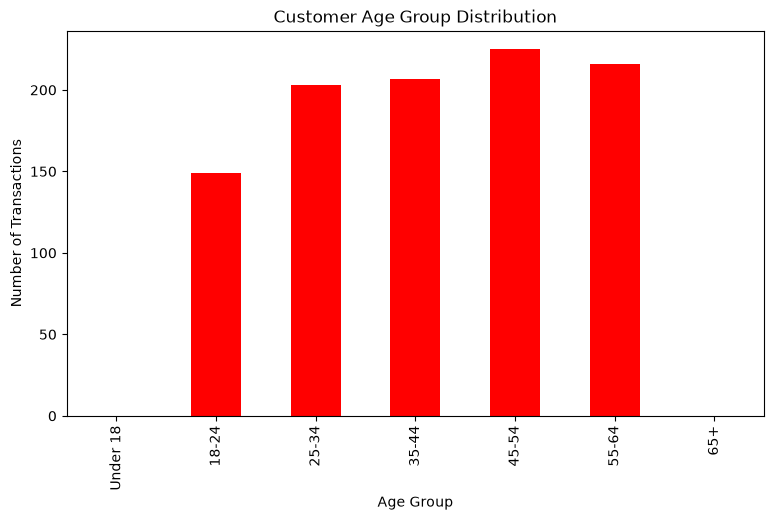

In [78]:
plt.figure(figsize=(9, 5))

age_group_counts.plot(kind="bar",color="red")

plt.title("Customer Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Transactions")

plt.show()

## Product quantity analysis

In [45]:
category_quantity = df.groupby("Product Category")["Quantity"].sum()

category_quantity

Product Category
Beauty         771
Clothing       894
Electronics    849
Name: Quantity, dtype: int64

In [46]:
category_quantity = category_quantity.sort_values(ascending=False)

category_quantity


Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64

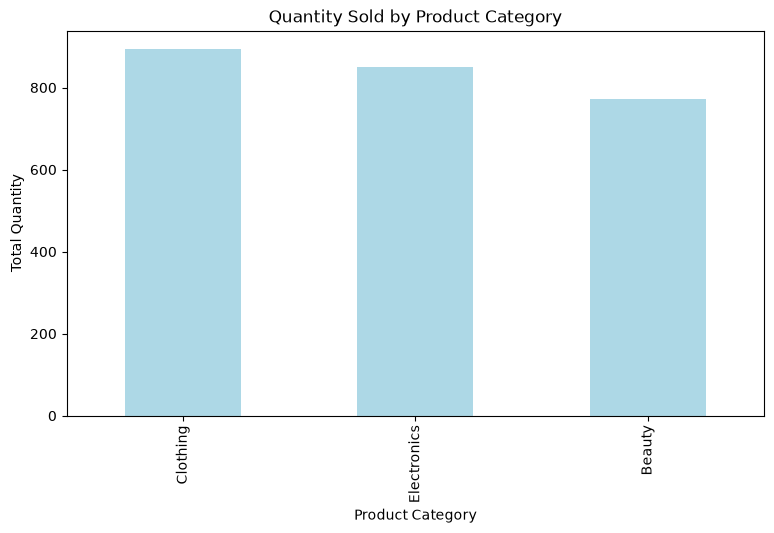

In [79]:
plt.figure(figsize=(9, 5))

category_quantity.plot(kind="bar",color="lightblue")

plt.title("Quantity Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Quantity")

plt.show()

## PRODUCT  revenue analysis

In [48]:
category_revenue = df.groupby("Product Category")["Total Amount"].sum()

category_revenue

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64

In [49]:
category_revenue = category_revenue.sort_values(ascending=False)
category_revenue

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

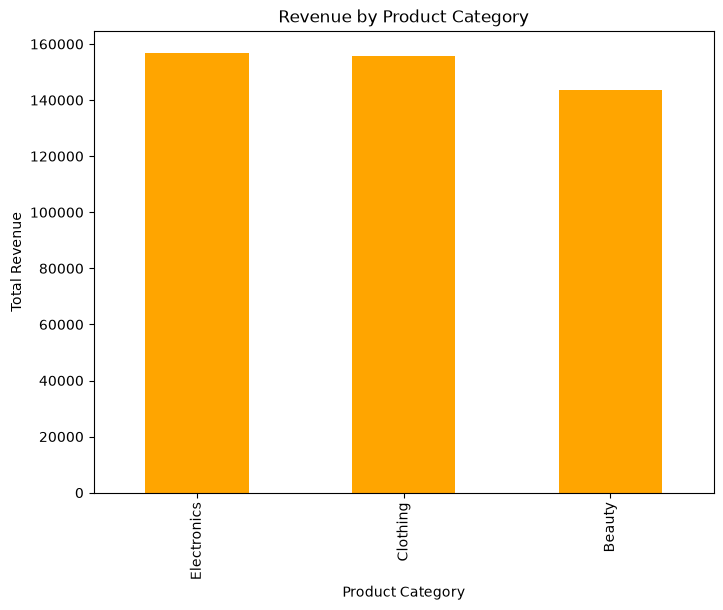

In [50]:
plt.figure(figsize=(8,6))
category_revenue.plot(kind="bar", color="orange")
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.show()

## Correlation analysis

In [52]:
correlation = df[
    ["Age", "Quantity", "Price per Unit", "Total Amount"]
].corr()

correlation

,Age,Quantity,Price per Unit,Total Amount
Age,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.060568,0.373707,0.851925,1.000000


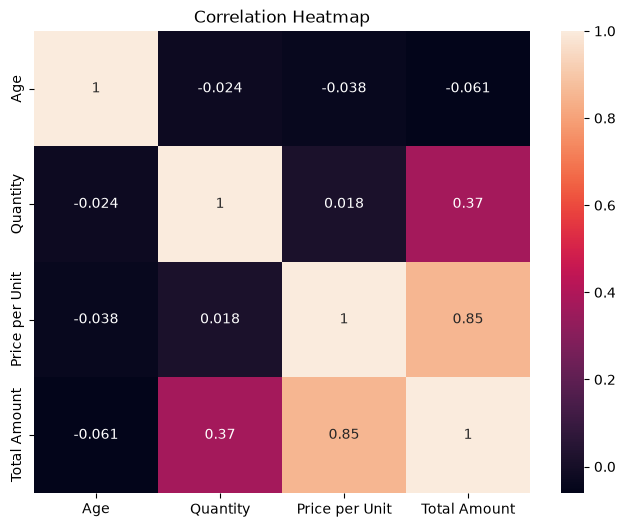

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

## Additional visualization like age group spending money

In [54]:
age_group_spending = df.groupby("Age Group", observed=True)["Total Amount"].mean()

age_group_spending


Age Group
18-24    501.006711
25-34    478.275862
35-44    467.801932
45-54    432.155556
55-64    417.546296
Name: Total Amount, dtype: float64

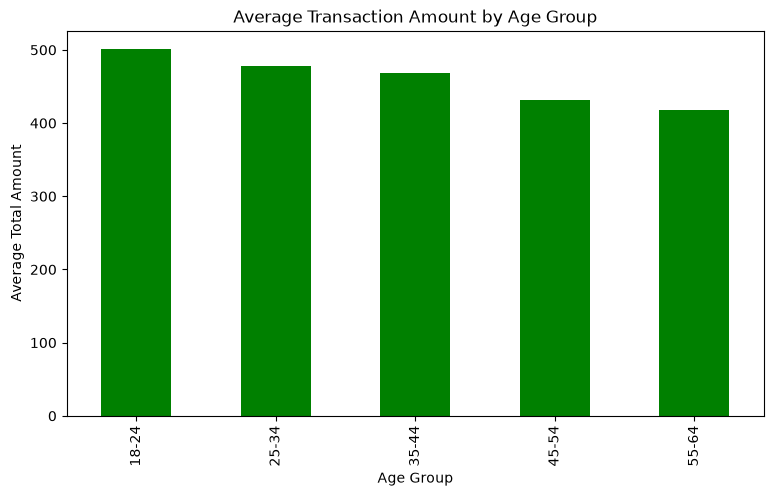

In [60]:
plt.figure(figsize=(9, 5))

age_group_spending.plot(kind="bar" ,color="green")

plt.title("Average Transaction Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Total Amount")

plt.show()

## Additional visualization

In [72]:
print("Highest Quarterly Sales:")
print(quarterly_sales.idxmax(), quarterly_sales.max())

print("\nLowest Quarterly Sales:")
print(quarterly_sales.idxmin(), quarterly_sales.min())

print("\nHighest Quantity Category:")
print(category_quantity.idxmax(), category_quantity.max())

print("\nHighest Revenue Category:")
print(category_revenue.idxmax(), category_revenue.max())

print("\nHighest Average Spending Age Group:")
print(age_group_spending.idxmax(), age_group_spending.max())

print("\nLowest Average Spending Age Group:")
print(age_group_spending.idxmin(), age_group_spending.min())

Highest Quarterly Sales:
4 126190

Lowest Quarterly Sales:
3 96045

Highest Quantity Category:
Clothing 894

Highest Revenue Category:
Electronics 156905

Highest Average Spending Age Group:
18-24 501.00671140939596

Lowest Average Spending Age Group:
55-64 417.5462962962963


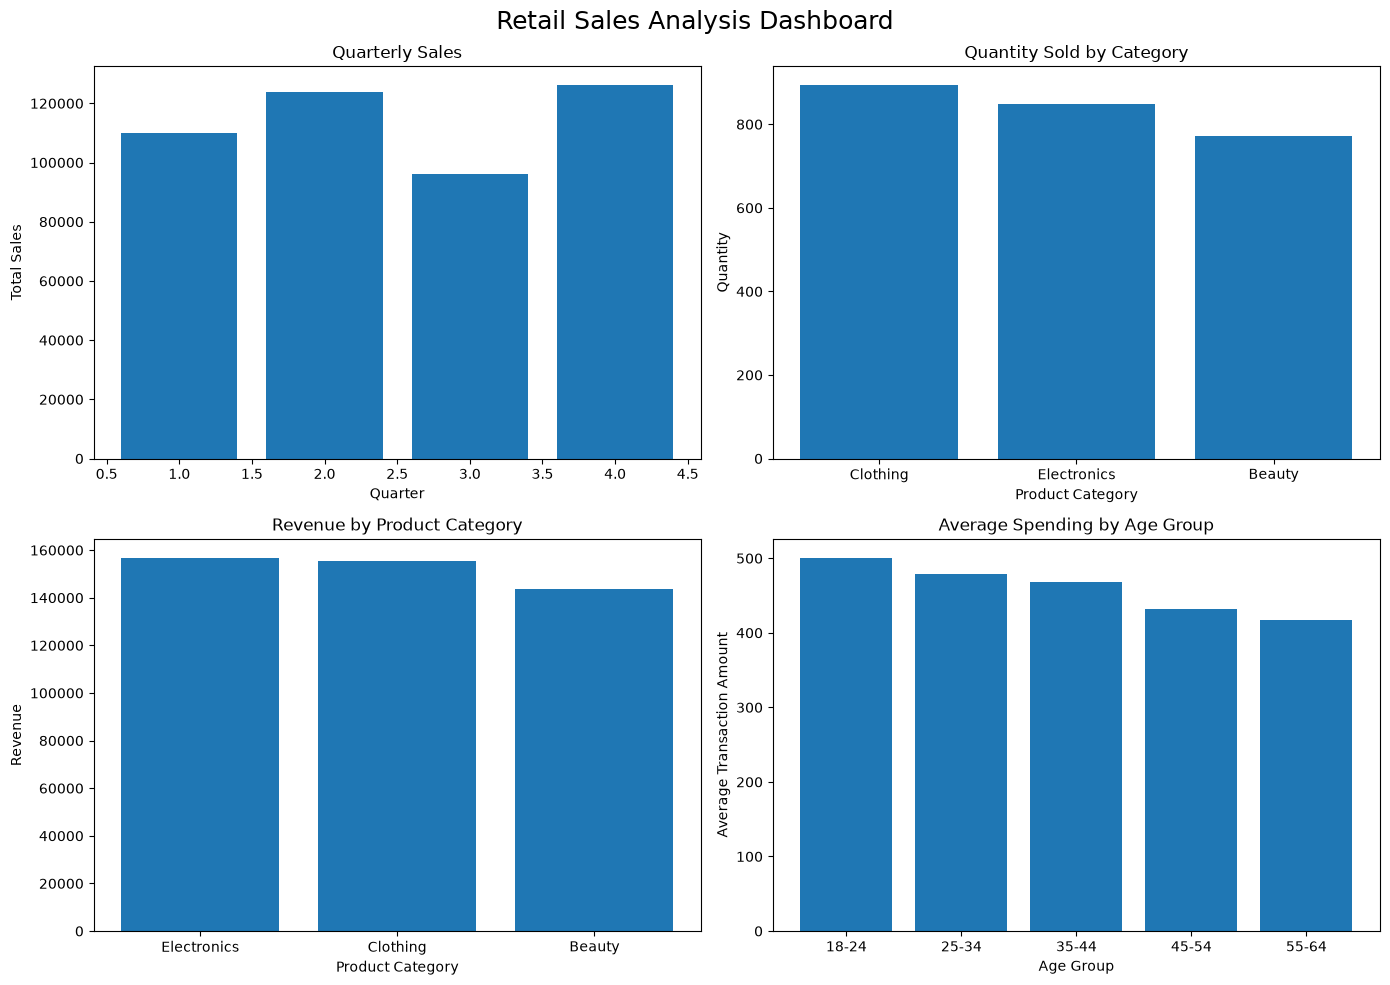

In [73]:
import matplotlib.pyplot as plt

# Create dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Quarterly Sales
axes[0, 0].bar(
    quarterly_sales.index,
    quarterly_sales.values
)
axes[0, 0].set_title("Quarterly Sales")
axes[0, 0].set_xlabel("Quarter")
axes[0, 0].set_ylabel("Total Sales")

# 2. Quantity by Product Category
axes[0, 1].bar(
    category_quantity.index,
    category_quantity.values
)
axes[0, 1].set_title("Quantity Sold by Category")
axes[0, 1].set_xlabel("Product Category")
axes[0, 1].set_ylabel("Quantity")

# 3. Revenue by Product Category
axes[1, 0].bar(
    category_revenue.index,
    category_revenue.values
)
axes[1, 0].set_title("Revenue by Product Category")
axes[1, 0].set_xlabel("Product Category")
axes[1, 0].set_ylabel("Revenue")

# 4. Average Spending by Age Group
axes[1, 1].bar(
    age_group_spending.index,
    age_group_spending.values
)
axes[1, 1].set_title("Average Spending by Age Group")
axes[1, 1].set_xlabel("Age Group")
axes[1, 1].set_ylabel("Average Transaction Amount")

# Overall title
fig.suptitle(
    "Retail Sales Analysis Dashboard",
    fontsize=18
)

plt.tight_layout()
plt.show()

## Business Recommendations

1. Electronics generated the highest revenue, so the business should closely monitor Electronics inventory and identify the products contributing most to revenue.

2. Clothing recorded the highest quantity sold, indicating strong sales volume. The business should maintain adequate stock and identify the most popular Clothing products.

3. Customers aged 18–24 had the highest average transaction amount. The business could analyze their purchasing patterns and develop targeted offers based on their product preferences.

4. Price per Unit showed a strong positive correlation with Total Amount (0.852). The business should monitor pricing and product mix carefully when evaluating transaction value.

## Conclusion

This retail sales analysis provided insights into sales trends, customer demographics, product performance, and purchasing behavior. Q4 recorded the highest quarterly sales of 126,190, while Q3 recorded the lowest at 96,045. Clothing had the highest quantity sold with 894 units, whereas Electronics generated the highest revenue of 156,905. Customers aged 18–24 had the highest average transaction amount, while the 55–64 age group had the lowest. The correlation analysis also showed a strong positive relationship between Price per Unit and Total Amount, with a correlation of approximately 0.852. These findings can help the business understand customer behavior, identify strong-performing product categories, and support data-driven decisions.